# Economy, Energy Mix, and Responsibility in Global CO2 Emissions

This notebook asks: **why do national CO2 emissions differ so sharply, and which accounting lens changes the answer?**

The argument is more nuanced than "rich countries emit more." Economic development is strongly associated with higher emissions per person, but the final emissions outcome also depends on energy demand, fuel mix, trade accounting, land-use change, and long-run structural change.

**Investigation map**

| Section | Claim tested | Evidence used |
|---|---|---|
| Data audit | The raw OWID panel has uneven coverage, so each hypothesis needs its own defensible year/sample. | Missingness, country coverage, codebook units |
| Baseline | National emissions responsibility is concentrated, not evenly distributed. | Top-emitter shares, Lorenz curve, Gini index |
| H1 Economy | GDP per capita predicts CO2 per capita, but not CO2 per GDP. | Spearman correlations, labeled scatterplots |
| H2 Energy mix | Energy demand and coal share explain more than GDP alone. | Permutation test, bootstrap interval, OLS model comparison |
| H3 Trade/change | Production vs consumption accounting changes responsibility; post-1990 paths diverge. | Trade-adjusted emissions, indexed time series |
| H4 Land use | Fossil CO2 alone can understate emissions in land-use-intensive economies. | CO2 with and without land-use change |


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Robust paths: works whether the kernel starts in the repo root or notebooks/.
for candidate in [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]:
    if (candidate / 'data/raw/owid-co2-data.csv').exists():
        PROJECT_ROOT = candidate
        break
else:
    raise FileNotFoundError('Could not find data/raw/owid-co2-data.csv')

DATA = PROJECT_ROOT / 'data/raw/owid-co2-data.csv'
CODEBOOK = PROJECT_ROOT / 'data/raw/owid-co2-codebook.csv'
FIGURES = PROJECT_ROOT / 'figures'
FIGURES.mkdir(exist_ok=True)

plt.rcParams.update({
    'figure.figsize': (8, 5),
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.25,
    'font.size': 10,
})

pd.options.display.float_format = '{:,.3f}'.format

df = pd.read_csv(DATA)
codebook = pd.read_csv(CODEBOOK)
countries = df[df['iso_code'].notna() & (df['iso_code'].str.len() == 3)].copy()

print('Rows, columns:', df.shape)
print('Years:', int(df['year'].min()), 'to', int(df['year'].max()))
print('Country-year rows after aggregate removal:', countries.shape[0])
print('Countries/territories with ISO codes:', countries['country'].nunique())
countries.head()


Rows, columns: (50411, 79)
Years: 1750 to 2024
Country-year rows after aggregate removal: 42480
Countries/territories with ISO codes: 218


,country,year,iso_code,population,gdp,cement_co2,cement_co2_per_capita,co2,co2_growth_abs,co2_growth_prct,...,share_global_other_co2,share_of_temperature_change_from_ghg,temperature_change_from_ch4,temperature_change_from_co2,temperature_change_from_ghg,temperature_change_from_n2o,total_ghg,total_ghg_excluding_lucf,trade_co2,trade_co2_share
0,Afghanistan,1750,AFG,"2,802,560.000",NaN,0.000,0.000,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Afghanistan,1751,AFG,NaN,NaN,0.000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Afghanistan,1752,AFG,NaN,NaN,0.000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Afghanistan,1753,AFG,NaN,NaN,0.000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Afghanistan,1754,AFG,NaN,NaN,0.000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Data and Scope

The analysis uses the Our World in Data CO2 dataset. It includes country-year observations for emissions, population, GDP, energy use, fuel-specific emissions, consumption-based emissions, and trade-adjusted emissions.

Different indicators have different latest usable years, so we use the newest year with broad country coverage for each question:

- 2022 for GDP-heavy and energy-per-capita analysis.
- 2023 for consumption and trade-adjusted emissions.
- 2024 for fuel-mix and latest territorial emissions analysis.

Countries with very small populations are filtered out in the hypothesis tests to keep microstate outliers from driving the results. The analysis is observational, so it tests associations and structural patterns rather than proving a single policy caused a national emissions path.


,column,title,unit
0,co2,Annual CO₂ emissions,million tonnes (Mt)
1,co2_including_luc,Annual CO₂ emissions including land-use change,million tonnes (Mt)
2,co2_per_capita,CO₂ emissions per capita,tonnes per person (t/person)
3,co2_per_gdp,Annual CO₂ emissions per GDP (kg per internati...,kilograms per international-$ (kg/$)
4,co2_per_unit_energy,Annual CO₂ emissions per unit energy (kg per k...,kilograms per kilowatt-hour (kg/kWh)
5,coal_co2,Annual CO₂ emissions from coal,million tonnes (Mt)
6,consumption_co2,Annual consumption-based CO₂ emissions,million tonnes (Mt)
7,energy_per_capita,Primary energy consumption per capita,kilowatt-hours per person (kWh)
8,gas_co2,Annual CO₂ emissions from gas,million tonnes (Mt)
9,gdp,Gross domestic product (GDP),international-$ in 2011 prices ($)


,section,latest_year_with_80plus_countries,country_count,required_columns
0,GDP + population + CO2,2022,164,"gdp, population, co2, co2_per_capita"
1,Trade/consumption CO2,2023,120,"consumption_co2, trade_co2_share, co2"
2,Energy intensity,2023,203,"energy_per_capita, co2_per_unit_energy"
3,Fuel mix,2024,110,"coal_co2, oil_co2, gas_co2, co2"
4,Land-use accounting,2024,194,"co2, co2_including_luc, land_use_change_co2"


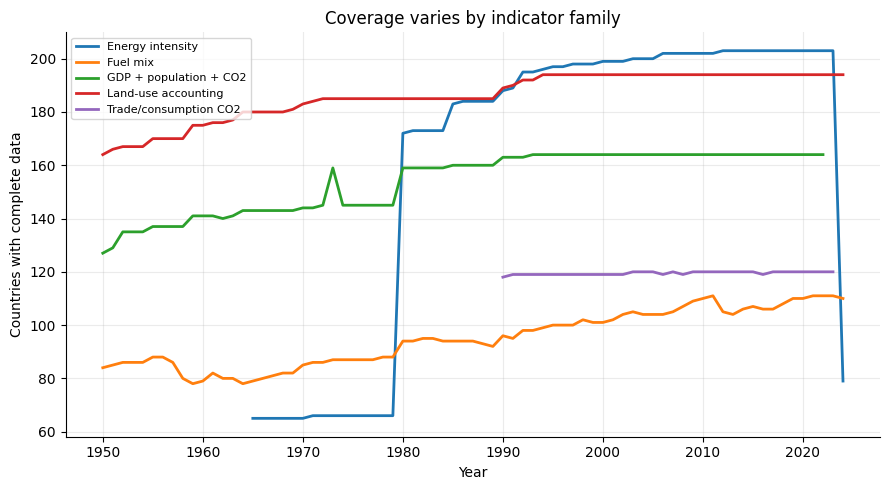

In [2]:
key_columns = [
    'co2', 'co2_per_capita', 'co2_per_gdp', 'co2_per_unit_energy',
    'gdp', 'population', 'energy_per_capita', 'coal_co2', 'oil_co2', 'gas_co2',
    'consumption_co2', 'trade_co2_share', 'co2_including_luc', 'land_use_change_co2',
]

variable_glossary = (
    codebook[codebook['column'].isin(key_columns)]
    [['column', 'title', 'unit']]
    .sort_values('column')
    .reset_index(drop=True)
)
display(variable_glossary)

coverage_specs = {
    'GDP + population + CO2': ['gdp', 'population', 'co2', 'co2_per_capita'],
    'Trade/consumption CO2': ['consumption_co2', 'trade_co2_share', 'co2'],
    'Energy intensity': ['energy_per_capita', 'co2_per_unit_energy'],
    'Fuel mix': ['coal_co2', 'oil_co2', 'gas_co2', 'co2'],
    'Land-use accounting': ['co2', 'co2_including_luc', 'land_use_change_co2'],
}

rows = []
coverage_by_year = []
for label, cols in coverage_specs.items():
    valid = countries.dropna(subset=cols)
    counts = valid.groupby('year').size()
    latest = counts[counts >= 80].index.max()
    rows.append({
        'section': label,
        'latest_year_with_80plus_countries': latest,
        'country_count': int(counts.loc[latest]),
        'required_columns': ', '.join(cols),
    })
    for year, count in counts.items():
        coverage_by_year.append({'year': year, 'section': label, 'country_count': count})

coverage_table = pd.DataFrame(rows)
display(coverage_table)

coverage_plot = pd.DataFrame(coverage_by_year)
fig, ax = plt.subplots(figsize=(9, 5))
for label, group in coverage_plot[coverage_plot['year'] >= 1950].groupby('section'):
    ax.plot(group['year'], group['country_count'], label=label, linewidth=2)
ax.set_title('Coverage varies by indicator family')
ax.set_xlabel('Year')
ax.set_ylabel('Countries with complete data')
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIGURES / 'audit_coverage_by_year.png', dpi=180)
plt.show()


In [3]:
def spearman_corr(x, y):
    return pd.Series(x).rank(method='average').corr(pd.Series(y).rank(method='average'))


def permutation_corr_test(x, y, n=2000, seed=0):
    rng = np.random.default_rng(seed)
    x = np.array(x, copy=True, dtype=float)
    y = np.array(y, copy=True, dtype=float)
    observed = spearman_corr(x, y)
    count = 0
    for _ in range(n):
        if abs(spearman_corr(x, rng.permutation(y))) >= abs(observed):
            count += 1
    return observed, (count + 1) / (n + 1)


def permutation_mean_test(a, b, n=5000, seed=1):
    rng = np.random.default_rng(seed)
    a = np.array(a, copy=True, dtype=float)
    b = np.array(b, copy=True, dtype=float)
    observed = a.mean() - b.mean()
    pool = np.concatenate([a, b])
    n_a = len(a)
    count = 0
    for _ in range(n):
        permuted = rng.permutation(pool)
        diff = permuted[:n_a].mean() - permuted[n_a:].mean()
        if abs(diff) >= abs(observed):
            count += 1
    return observed, (count + 1) / (n + 1)


def gini(values):
    x = np.sort(np.asarray(values, dtype=float))
    x = x[np.isfinite(x)]
    x = x[x >= 0]
    if len(x) == 0 or x.sum() == 0:
        return np.nan
    n = len(x)
    return (2 * np.arange(1, n + 1) @ x) / (n * x.sum()) - (n + 1) / n


def fit_ols(X, y, feature_names):
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float)
    X_design = np.column_stack([np.ones(len(X)), X])
    beta = np.linalg.lstsq(X_design, y, rcond=None)[0]
    fitted = X_design @ beta
    residuals = y - fitted
    ss_res = np.sum(residuals ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    return {
        'terms': ['intercept'] + list(feature_names),
        'beta': beta,
        'fitted': fitted,
        'residuals': residuals,
        'r2': 1 - ss_res / ss_tot,
        'rmse': np.sqrt(np.mean(residuals ** 2)),
    }


def bootstrap_ols_ci(X, y, feature_names, n=1000, seed=3):
    rng = np.random.default_rng(seed)
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float)
    coefs = []
    for _ in range(n):
        idx = rng.integers(0, len(y), len(y))
        coefs.append(fit_ols(X[idx], y[idx], feature_names)['beta'])
    return np.percentile(np.asarray(coefs), [2.5, 50, 97.5], axis=0)


def label_points(ax, data, names, x, y, fontsize=8, x_scale=1):
    for name in names:
        row = data[data['country'] == name]
        if not row.empty:
            ax.annotate(
                name,
                (row[x].iloc[0] * x_scale, row[y].iloc[0]),
                fontsize=fontsize,
                xytext=(4, 3),
                textcoords='offset points',
            )


## Methods

We use five statistical tools to check the main chart patterns:

- **Spearman correlation** tests whether two variables move together in rank order. This is more appropriate than relying only on linear correlation because country-level CO2 variables are skewed and contain outliers.
- **Permutation tests** estimate how surprising an observed relationship would be if labels or values were randomly rearranged under a null hypothesis.
- **Bootstrap confidence intervals** estimate uncertainty in the coal-intensity gap without assuming that country emissions follow a normal distribution.
- **OLS model comparison** checks whether adding energy use and coal share improves prediction beyond GDP alone. This is associational, not causal.
- **Concentration measures** such as top-emitter share, Lorenz curves, and Gini index summarize how unequal national emissions are.

These checks come before the hypothesis sections because they explain how the results are evaluated.


In [4]:
# Construct the high-coal vs low-coal comparison used to validate H2A.
h2_methods = countries[countries['year'] == 2024].dropna(
    subset=['coal_co2', 'oil_co2', 'gas_co2', 'co2', 'co2_per_unit_energy', 'population']
).copy()
h2_methods = h2_methods[(h2_methods['population'] >= 1_000_000) & (h2_methods['co2'] > 20)]
h2_methods['known_fossil_co2'] = h2_methods[['coal_co2', 'oil_co2', 'gas_co2']].sum(axis=1)
h2_methods = h2_methods[h2_methods['known_fossil_co2'] > 0]
h2_methods['coal_share'] = h2_methods['coal_co2'] / h2_methods['known_fossil_co2']

high_coal = h2_methods[h2_methods['coal_share'] >= 0.5]['co2_per_unit_energy'].to_numpy()
low_coal = h2_methods[h2_methods['coal_share'] < 0.2]['co2_per_unit_energy'].to_numpy()
observed_gap = high_coal.mean() - low_coal.mean()

print(f'High-coal countries: n={len(high_coal)}, mean={high_coal.mean():.3f} kg CO2/kWh')
print(f'Low-coal countries: n={len(low_coal)}, mean={low_coal.mean():.3f} kg CO2/kWh')
print(f'Observed mean gap: {observed_gap:.3f} kg CO2/kWh')


High-coal countries: n=8, mean=0.274 kg CO2/kWh
Low-coal countries: n=39, mean=0.168 kg CO2/kWh
Observed mean gap: 0.106 kg CO2/kWh


### Permutation Test

The null hypothesis is that coal-heavy and low-coal labels are exchangeable. If coal share does not matter, randomly shuffling labels should often produce a gap as large as the observed gap. The p-value below is the fraction of shuffled-label simulations that produce an absolute mean gap at least as large as the real one.


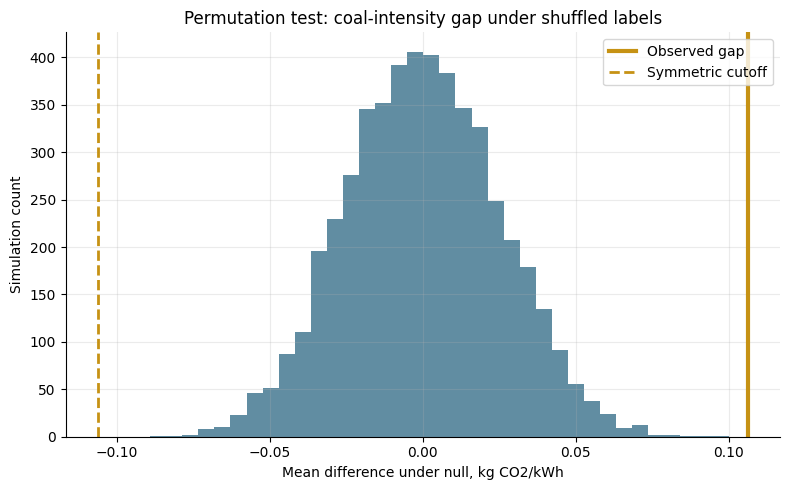

,observed_gap,permutation_p_value,simulations
0,0.106,0.000,5000


In [5]:
rng = np.random.default_rng(328)
pool = np.concatenate([high_coal, low_coal])
perm_diffs = []
for _ in range(5000):
    permuted = rng.permutation(pool)
    perm_diffs.append(permuted[:len(high_coal)].mean() - permuted[len(high_coal):].mean())
perm_diffs = np.array(perm_diffs)
perm_p = (np.sum(np.abs(perm_diffs) >= abs(observed_gap)) + 1) / (len(perm_diffs) + 1)

fig, ax = plt.subplots()
ax.hist(perm_diffs, bins=36, color='#356d88', alpha=0.78)
ax.axvline(observed_gap, color='#c69214', linewidth=3, label='Observed gap')
ax.axvline(-observed_gap, color='#c69214', linewidth=2, linestyle='--', label='Symmetric cutoff')
ax.set_title('Permutation test: coal-intensity gap under shuffled labels')
ax.set_xlabel('Mean difference under null, kg CO2/kWh')
ax.set_ylabel('Simulation count')
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES / 'methods_permutation_test.png', dpi=180)
plt.show()

pd.DataFrame([{
    'observed_gap': observed_gap,
    'permutation_p_value': perm_p,
    'simulations': len(perm_diffs),
}])

### Bootstrap Confidence Interval

The bootstrap resamples high-coal and low-coal countries with replacement and recomputes the mean gap. This gives uncertainty bounds for the estimated coal-intensity difference without assuming a normal population distribution.


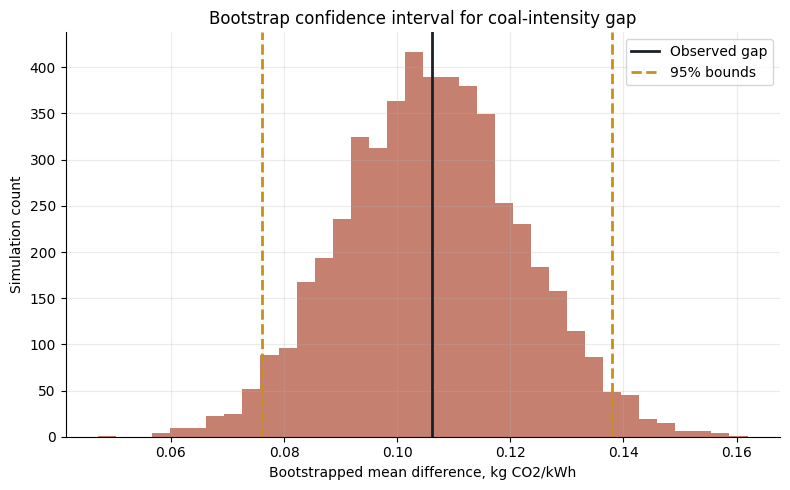

,observed_gap,ci_lower_2_5_pct,ci_upper_97_5_pct
0,0.106,0.076,0.138


In [6]:
boot_diffs = []
for _ in range(5000):
    boot_high = rng.choice(high_coal, size=len(high_coal), replace=True)
    boot_low = rng.choice(low_coal, size=len(low_coal), replace=True)
    boot_diffs.append(boot_high.mean() - boot_low.mean())
boot_diffs = np.array(boot_diffs)
ci_low, ci_high = np.percentile(boot_diffs, [2.5, 97.5])

fig, ax = plt.subplots()
ax.hist(boot_diffs, bins=36, color='#b4553f', alpha=0.75)
ax.axvline(observed_gap, color='#192026', linewidth=2, label='Observed gap')
ax.axvline(ci_low, color='#c69214', linewidth=2, linestyle='--', label='95% bounds')
ax.axvline(ci_high, color='#c69214', linewidth=2, linestyle='--')
ax.set_title('Bootstrap confidence interval for coal-intensity gap')
ax.set_xlabel('Bootstrapped mean difference, kg CO2/kWh')
ax.set_ylabel('Simulation count')
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES / 'methods_bootstrap_bounds.png', dpi=180)
plt.show()

pd.DataFrame([{
    'observed_gap': observed_gap,
    'ci_lower_2_5_pct': ci_low,
    'ci_upper_97_5_pct': ci_high,
}])

### Central Limit Theorem Check

The distribution of country CO2 per capita is highly skewed, but repeated sample means are smoother and more concentrated around the population mean. This is a sanity check for why averages and confidence intervals can still be informative, while also reminding us that outliers must be handled carefully.


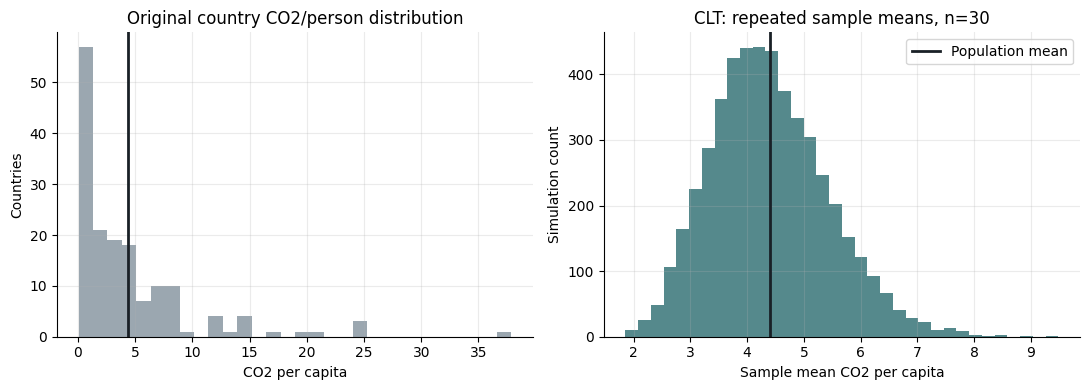

,population_mean,mean_of_sample_means,standard_error_simulated,sample_size
0,4.395,4.390,1.031,30


In [7]:
co2pc_2022 = countries[(countries['year'] == 2022) & (countries['population'] >= 1_000_000)]['co2_per_capita'].dropna().to_numpy()
sample_size = 30
sample_means = np.array([
    rng.choice(co2pc_2022, size=sample_size, replace=True).mean()
    for _ in range(5000)
])

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(co2pc_2022, bins=30, color='#8a98a3', alpha=0.85)
axes[0].axvline(co2pc_2022.mean(), color='#192026', linewidth=2)
axes[0].set_title('Original country CO2/person distribution')
axes[0].set_xlabel('CO2 per capita')
axes[0].set_ylabel('Countries')

axes[1].hist(sample_means, bins=34, color='#2f6f73', alpha=0.82)
axes[1].axvline(co2pc_2022.mean(), color='#192026', linewidth=2, label='Population mean')
axes[1].set_title('CLT: repeated sample means, n=30')
axes[1].set_xlabel('Sample mean CO2 per capita')
axes[1].set_ylabel('Simulation count')
axes[1].legend()

fig.tight_layout()
fig.savefig(FIGURES / 'methods_clt_sample_means.png', dpi=180)
plt.show()

pd.DataFrame([{
    'population_mean': co2pc_2022.mean(),
    'mean_of_sample_means': sample_means.mean(),
    'standard_error_simulated': sample_means.std(ddof=1),
    'sample_size': sample_size,
}])

### K-means Clustering

K-means groups countries using standardized 2022 values of log GDP per capita, log energy per capita, CO2 per capita, and CO2 per GDP. The clusters are not moral categories and not causal proof; they are a compact way to show that countries occupy different emissions profiles.


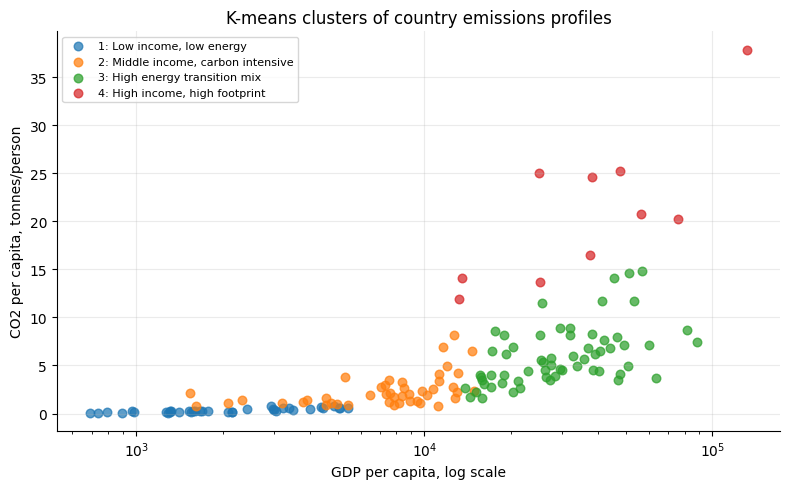

,cluster,cluster_name,countries,avg_gdp_per_capita,avg_energy_per_capita,avg_co2_per_capita,avg_co2_per_gdp
0,1,"Low income, low energy",37,"2,391.718","1,407.265",0.332,0.142
1,2,"Middle income, carbon intensive",45,"8,138.788","9,828.472",2.376,0.326
2,3,High energy transition mix,61,"32,741.217","36,964.033",6.025,0.200
3,4,"High income, high footprint",10,"46,526.598","101,628.520",21.006,0.603


In [8]:
cluster_df = countries[countries['year'] == 2022].dropna(
    subset=['gdp', 'population', 'energy_per_capita', 'co2_per_capita', 'co2_per_gdp']
).copy()
cluster_df = cluster_df[cluster_df['population'] >= 1_000_000]
cluster_df['gdp_per_capita'] = cluster_df['gdp'] / cluster_df['population']

features = np.column_stack([
    np.log10(cluster_df['gdp_per_capita']),
    np.log10(cluster_df['energy_per_capita']),
    cluster_df['co2_per_capita'],
    cluster_df['co2_per_gdp'],
])
z = (features - features.mean(axis=0)) / features.std(axis=0)

k = 4
order = np.argsort(z[:, 0])
centroids = z[order[np.linspace(0, len(order) - 1, k, dtype=int)]].copy()
labels = np.zeros(len(z), dtype=int)
for _ in range(100):
    distances = ((z[:, None, :] - centroids[None, :, :]) ** 2).sum(axis=2)
    new_labels = distances.argmin(axis=1)
    if np.array_equal(labels, new_labels):
        break
    labels = new_labels
    for group in range(k):
        if np.any(labels == group):
            centroids[group] = z[labels == group].mean(axis=0)

cluster_df['cluster_raw'] = labels
ranked = cluster_df.groupby('cluster_raw')['gdp_per_capita'].mean().sort_values().index.tolist()
cluster_df['cluster'] = cluster_df['cluster_raw'].map({raw: idx for idx, raw in enumerate(ranked, start=1)})
cluster_names = {
    1: 'Low income, low energy',
    2: 'Middle income, carbon intensive',
    3: 'High energy transition mix',
    4: 'High income, high footprint',
}
cluster_df['cluster_name'] = cluster_df['cluster'].map(cluster_names)

fig, ax = plt.subplots()
for cluster_id, group in cluster_df.groupby('cluster'):
    ax.scatter(
        group['gdp_per_capita'],
        group['co2_per_capita'],
        s=38,
        alpha=0.72,
        label=f'{cluster_id}: {cluster_names[cluster_id]}',
    )
ax.set_xscale('log')
ax.set_xlabel('GDP per capita, log scale')
ax.set_ylabel('CO2 per capita, tonnes/person')
ax.set_title('K-means clusters of country emissions profiles')
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIGURES / 'methods_kmeans_clusters.png', dpi=180)
plt.show()

cluster_summary = cluster_df.groupby(['cluster', 'cluster_name']).agg(
    countries=('country', 'count'),
    avg_gdp_per_capita=('gdp_per_capita', 'mean'),
    avg_energy_per_capita=('energy_per_capita', 'mean'),
    avg_co2_per_capita=('co2_per_capita', 'mean'),
    avg_co2_per_gdp=('co2_per_gdp', 'mean'),
).reset_index()
cluster_summary

### Methods Takeaway

The statistical checks support the main results. The coal-intensity gap is unlikely under random label shuffling, the bootstrap interval stays above zero, the CLT check explains why sample means are useful despite skew, and k-means shows that countries fall into distinct emissions profiles rather than a simple rich/poor binary.


## Global Baseline: Emissions Are Concentrated

Before testing country-level hypotheses, we need the shape of the problem. If emissions were evenly distributed across countries, a single average would be a tolerable summary. They are not.

**Baseline claim:** national emissions responsibility is highly concentrated, so total emissions, per-capita emissions, and cumulative emissions answer different questions.


In [9]:
latest_year = int(countries['year'].max())
latest = countries[(countries['year'] == latest_year) & countries['co2'].notna()].copy()
latest = latest[latest['co2'] > 0]
latest['annual_share_calc'] = 100 * latest['co2'] / latest['co2'].sum()

top10 = latest.nlargest(10, 'co2').copy()
top10_share = top10['co2'].sum() / latest['co2'].sum() * 100
annual_gini = gini(latest['co2'])

cum_latest = countries[(countries['year'] == latest_year) & countries['cumulative_co2'].notna()].copy()
cum_latest = cum_latest[cum_latest['cumulative_co2'] > 0]
cum_top10_share = cum_latest.nlargest(10, 'cumulative_co2')['cumulative_co2'].sum() / cum_latest['cumulative_co2'].sum() * 100
cum_gini = gini(cum_latest['cumulative_co2'])

summary = pd.DataFrame([{
    'year': latest_year,
    'countries_with_positive_annual_co2': len(latest),
    'top10_share_of_annual_co2_pct': top10_share,
    'annual_co2_gini': annual_gini,
    'top10_share_of_cumulative_co2_pct': cum_top10_share,
    'cumulative_co2_gini': cum_gini,
}])
display(summary)

top10[['country', 'co2', 'annual_share_calc', 'co2_per_capita']].rename(columns={
    'co2': 'annual_co2_Mt',
    'annual_share_calc': 'share_of_world_pct',
    'co2_per_capita': 'co2_per_capita_t',
})


,year,countries_with_positive_annual_co2,top10_share_of_annual_co2_pct,annual_co2_gini,top10_share_of_cumulative_co2_pct,cumulative_co2_gini
0,2024,213,71.079,0.894,69.914,0.891


,country,annual_co2_Mt,share_of_world_pct,co2_per_capita_t
9933,China,"12,289.037",32.860,8.658
48007,United States,"4,904.120",13.113,14.197
21762,India,"3,193.478",8.539,2.201
38314,Russia,"1,780.524",4.761,12.295
23812,Japan,961.867,2.572,7.772
21937,Indonesia,812.220,2.172,2.865
22662,Iran,792.631,2.119,8.656
40289,Saudi Arabia,692.133,1.851,20.379
43038,South Korea,583.679,1.561,11.286
18319,Germany,572.319,1.530,6.769


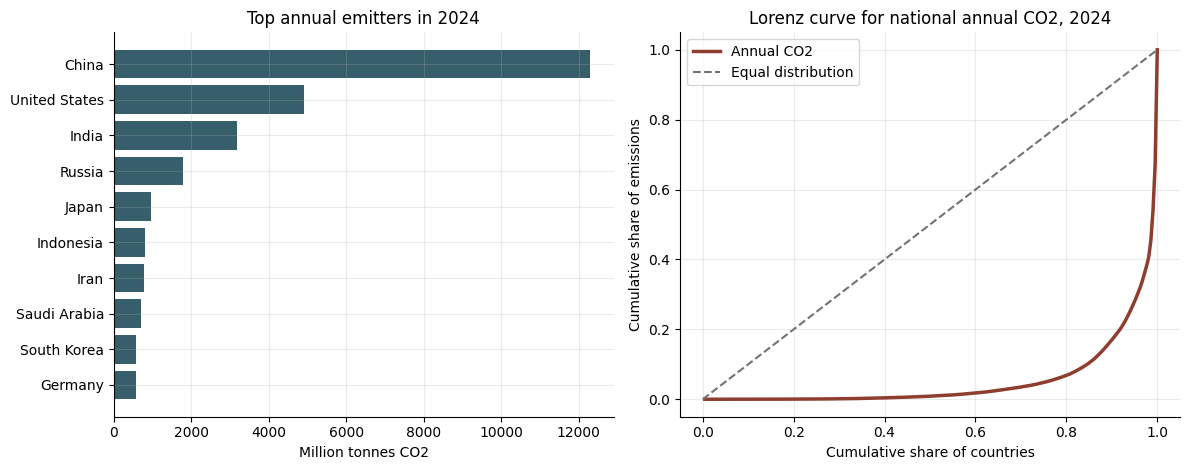

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

plot_top = top10.sort_values('co2')
axes[0].barh(plot_top['country'], plot_top['co2'], color='#365f6b')
axes[0].set_title(f'Top annual emitters in {latest_year}')
axes[0].set_xlabel('Million tonnes CO2')

x = np.sort(latest['co2'].to_numpy())
cum_countries = np.arange(1, len(x) + 1) / len(x)
cum_emissions = np.cumsum(x) / x.sum()
axes[1].plot(cum_countries, cum_emissions, color='#8f3d2e', linewidth=2.5, label='Annual CO2')
axes[1].plot([0, 1], [0, 1], color='0.45', linestyle='--', label='Equal distribution')
axes[1].set_title(f'Lorenz curve for national annual CO2, {latest_year}')
axes[1].set_xlabel('Cumulative share of countries')
axes[1].set_ylabel('Cumulative share of emissions')
axes[1].legend()

fig.tight_layout()
fig.savefig(FIGURES / 'baseline_concentration_top_emitters_lorenz.png', dpi=180)
plt.show()


### Baseline Interpretation

The baseline supports treating emissions as a concentration problem. In the latest territorial CO2 year, the ten largest emitters account for most reported annual emissions, and the Lorenz curve is far from the equality line. Smaller countries still matter for per-capita and consumption-based responsibility, but the global mitigation arithmetic is dominated by a relatively small set of large national systems.


## Results and Interpretation

The three hypotheses below build from direct national emissions patterns to broader questions of responsibility. Hypothesis 1 tests whether wealth explains emissions, Hypothesis 2 tests the role of energy demand and fuel mix, and Hypothesis 3 compares territorial responsibility with consumption responsibility over time.


## Hypothesis 1: Economy

**H1A:** Higher GDP per capita is associated with higher CO2 per capita.

**H1B:** GDP per capita alone does not reliably predict CO2 per GDP; energy mix and economic structure explain variation better.


In [11]:
h1 = countries[countries['year'] == 2022].dropna(
    subset=['gdp', 'population', 'co2_per_capita', 'co2_per_gdp']
).copy()
h1 = h1[h1['population'] >= 1_000_000]
h1['gdp_per_capita'] = h1['gdp'] / h1['population']

stats_rows = []
for x, y, label in [
    ('gdp_per_capita', 'co2_per_capita', 'GDP per capita vs CO2 per capita'),
    ('gdp_per_capita', 'co2_per_gdp', 'GDP per capita vs CO2 per GDP'),
]:
    d = h1[[x, y]].dropna()
    r, p = permutation_corr_test(d[x], d[y], n=1000)
    stats_rows.append({'comparison': label, 'spearman_r': round(r, 3), 'permutation_p': round(p, 4), 'n': len(d)})

pd.DataFrame(stats_rows)

,comparison,spearman_r,permutation_p,n
0,GDP per capita vs CO2 per capita,0.891,0.001,153
1,GDP per capita vs CO2 per GDP,0.083,0.301,153


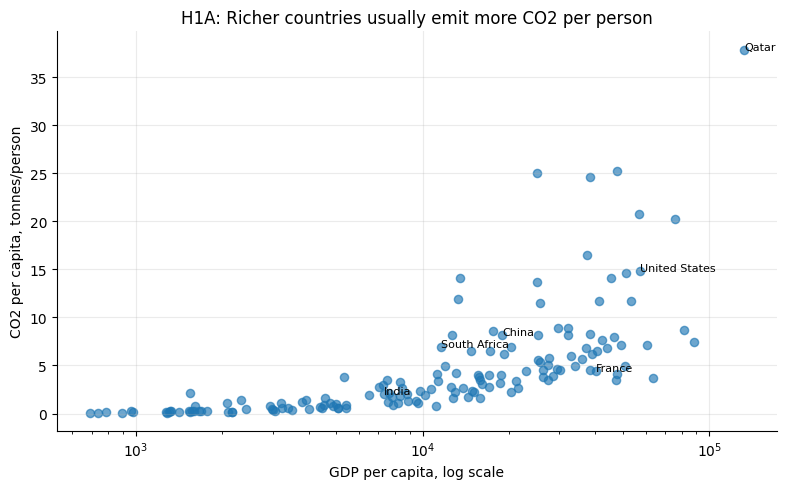

In [12]:
fig, ax = plt.subplots()
ax.scatter(h1['gdp_per_capita'], h1['co2_per_capita'], alpha=0.65, s=35)
ax.set_xscale('log')
ax.set_xlabel('GDP per capita, log scale')
ax.set_ylabel('CO2 per capita, tonnes/person')
ax.set_title('H1A: Richer countries usually emit more CO2 per person')

for name in ['United States', 'China', 'India', 'Qatar', 'France', 'South Africa']:
    row = h1[h1['country'] == name]
    if not row.empty:
        ax.annotate(name, (row['gdp_per_capita'].iloc[0], row['co2_per_capita'].iloc[0]), fontsize=8)

fig.tight_layout()
fig.savefig(FIGURES / 'h1a_gdp_vs_co2_per_capita.png', dpi=180)
plt.show()

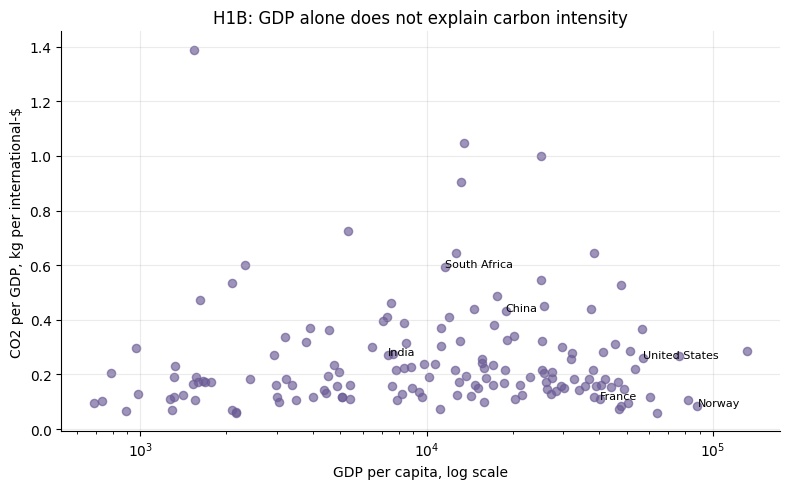

In [13]:
fig, ax = plt.subplots()
ax.scatter(h1['gdp_per_capita'], h1['co2_per_gdp'], alpha=0.65, s=35, color='#6b5b95')
ax.set_xscale('log')
ax.set_xlabel('GDP per capita, log scale')
ax.set_ylabel('CO2 per GDP, kg per international-$')
ax.set_title('H1B: GDP alone does not explain carbon intensity')

for name in ['China', 'India', 'South Africa', 'United States', 'France', 'Norway']:
    row = h1[h1['country'] == name]
    if not row.empty:
        ax.annotate(name, (row['gdp_per_capita'].iloc[0], row['co2_per_gdp'].iloc[0]), fontsize=8)

fig.tight_layout()
fig.savefig(FIGURES / 'h1b_gdp_vs_co2_per_gdp.png', dpi=180)
plt.show()

In [14]:
# Residual check: which countries are unusually carbon-intensive for their income level?
model_h1 = h1[['country', 'gdp_per_capita', 'co2_per_gdp']].dropna().copy()
X_h1 = np.log10(model_h1[['gdp_per_capita']].to_numpy())
y_h1 = model_h1['co2_per_gdp'].to_numpy()
fit_h1 = fit_ols(X_h1, y_h1, ['log10_gdp_per_capita'])
model_h1['predicted_co2_per_gdp'] = fit_h1['fitted']
model_h1['residual'] = model_h1['co2_per_gdp'] - model_h1['predicted_co2_per_gdp']

pd.concat([
    model_h1.nlargest(8, 'residual').assign(outlier_type='higher intensity than income predicts'),
    model_h1.nsmallest(8, 'residual').assign(outlier_type='lower intensity than income predicts'),
])[['outlier_type', 'country', 'gdp_per_capita', 'co2_per_gdp', 'predicted_co2_per_gdp', 'residual']]


,outlier_type,country,gdp_per_capita,co2_per_gdp,predicted_co2_per_gdp,residual
34458,higher intensity than income predicts,North Korea,"1,537.813",1.390,0.240,1.150
46426,higher intensity than income predicts,Turkmenistan,"13,485.517",1.047,0.251,0.796
45797,higher intensity than income predicts,Trinidad and Tobago,"25,077.082",0.999,0.254,0.745
30560,higher intensity than income predicts,Mongolia,"13,233.687",0.903,0.251,0.652
49159,higher intensity than income predicts,Venezuela,"5,305.426",0.724,0.246,0.478
26477,higher intensity than income predicts,Libya,"12,658.771",0.645,0.250,0.395
4512,higher intensity than income predicts,Bahrain,"38,324.938",0.644,0.256,0.388
44468,higher intensity than income predicts,Syria,"2,330.725",0.600,0.242,0.358
44293,lower intensity than income predicts,Switzerland,"63,623.009",0.059,0.258,-0.199
44118,lower intensity than income predicts,Sweden,"47,124.891",0.074,0.257,-0.183


### Interpretation: Economy

The economy section shows that wealth is strongly associated with emissions per person, but it is not a complete explanation of emissions intensity. Using 2022, the latest year with broad GDP coverage, countries with population above one million show a strong positive relationship between GDP per capita and CO2 per capita: the Spearman correlation is about 0.891. This supports H1A. Richer countries usually have larger homes, more transport, more electricity demand, and more energy-intensive consumption, so their average resident tends to be responsible for more CO2.

H1B is more interesting because the relationship nearly disappears when emissions are divided by GDP. GDP per capita and CO2 per GDP have a weak Spearman correlation of only about 0.083. The residual table makes the point concrete: some countries produce much more CO2 per dollar of output than their income level predicts, while service-heavy or cleaner-electricity economies often sit below the income-only expectation. The conclusion is that economic development increases per-person emissions, but GDP alone does not determine how dirty an economy is.


## Hypothesis 2: Energy Mix

**H2A:** Coal-heavy countries have higher CO2 emissions intensity.

**H2B:** Energy use per capita strongly predicts CO2 per capita, and adding energy demand plus coal share should outperform a GDP-only model.


In [15]:
h2 = countries[countries['year'] == 2024].dropna(
    subset=['coal_co2', 'oil_co2', 'gas_co2', 'co2', 'co2_per_unit_energy', 'population']
).copy()
h2 = h2[(h2['population'] >= 1_000_000) & (h2['co2'] > 20)]
h2['known_fossil_co2'] = h2[['coal_co2', 'oil_co2', 'gas_co2']].sum(axis=1)
h2 = h2[h2['known_fossil_co2'] > 0]
h2['coal_share'] = h2['coal_co2'] / h2['known_fossil_co2']

high_coal = h2[h2['coal_share'] >= 0.5]['co2_per_unit_energy'].dropna()
low_coal = h2[h2['coal_share'] < 0.2]['co2_per_unit_energy'].dropna()
diff, p = permutation_mean_test(high_coal, low_coal, n=2000)

pd.DataFrame([
    {'group': 'coal share >= 50%', 'n': len(high_coal), 'mean_co2_per_unit_energy': high_coal.mean()},
    {'group': 'coal share < 20%', 'n': len(low_coal), 'mean_co2_per_unit_energy': low_coal.mean()},
    {'group': 'difference and p-value', 'n': '', 'mean_co2_per_unit_energy': f'diff={diff:.3f}, p={p:.4f}'},
])

,group,n,mean_co2_per_unit_energy
0,coal share >= 50%,8,0.274
1,coal share < 20%,39,0.168
2,difference and p-value,,"diff=0.106, p=0.0005"


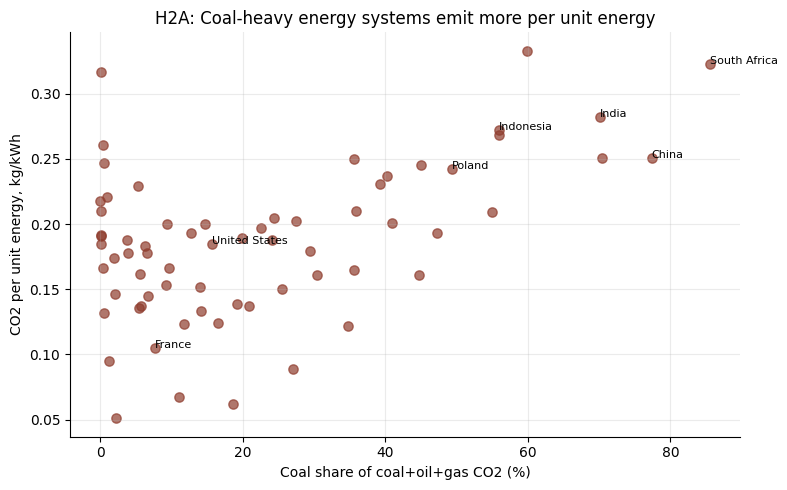

In [16]:
fig, ax = plt.subplots()
ax.scatter(h2['coal_share'] * 100, h2['co2_per_unit_energy'], alpha=0.7, s=45, color='#8f3d2e')
ax.set_xlabel('Coal share of coal+oil+gas CO2 (%)')
ax.set_ylabel('CO2 per unit energy, kg/kWh')
ax.set_title('H2A: Coal-heavy energy systems emit more per unit energy')

for name in ['South Africa', 'China', 'India', 'Indonesia', 'Poland', 'United States', 'France']:
    row = h2[h2['country'] == name]
    if not row.empty:
        ax.annotate(name, (row['coal_share'].iloc[0] * 100, row['co2_per_unit_energy'].iloc[0]), fontsize=8)

fig.tight_layout()
fig.savefig(FIGURES / 'h2a_coal_share_vs_energy_intensity.png', dpi=180)
plt.show()

Spearman r = 0.970, permutation p = 0.0010, n = 159


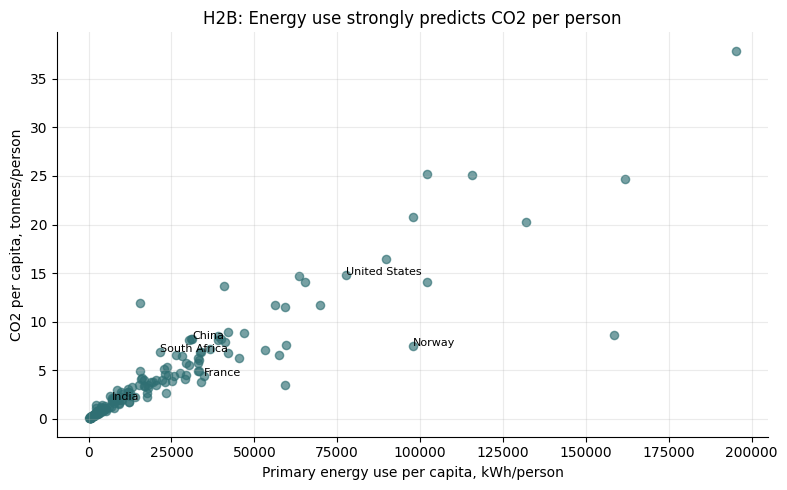

In [17]:
h2b = countries[countries['year'] == 2022].dropna(
    subset=['energy_per_capita', 'co2_per_capita', 'population']
).copy()
h2b = h2b[h2b['population'] >= 1_000_000]

r, p = permutation_corr_test(h2b['energy_per_capita'], h2b['co2_per_capita'], n=1000)
print(f'Spearman r = {r:.3f}, permutation p = {p:.4f}, n = {len(h2b)}')

fig, ax = plt.subplots()
ax.scatter(h2b['energy_per_capita'], h2b['co2_per_capita'], alpha=0.65, s=35, color='#2f6f73')
ax.set_xlabel('Primary energy use per capita, kWh/person')
ax.set_ylabel('CO2 per capita, tonnes/person')
ax.set_title('H2B: Energy use strongly predicts CO2 per person')

for name in ['United States', 'China', 'India', 'Norway', 'France', 'South Africa']:
    row = h2b[h2b['country'] == name]
    if not row.empty:
        ax.annotate(name, (row['energy_per_capita'].iloc[0], row['co2_per_capita'].iloc[0]), fontsize=8)

fig.tight_layout()
fig.savefig(FIGURES / 'h2b_energy_vs_co2_per_capita.png', dpi=180)
plt.show()

### Multivariate Check: Does Energy Add Explanatory Power Beyond GDP?

A high-scoring notebook should not stop at two scatterplots. Here we fit three simple OLS models for 2022 countries with population above 1 million. The outcome is `log10(co2_per_capita)`. Predictors are standardized, so coefficient sizes are comparable.


In [18]:
model_df = countries[countries['year'] == 2022].dropna(
    subset=['gdp', 'population', 'energy_per_capita', 'co2_per_capita', 'coal_co2', 'oil_co2', 'gas_co2']
).copy()
model_df = model_df[(model_df['population'] >= 1_000_000) & (model_df['gdp'] > 0) & (model_df['energy_per_capita'] > 0) & (model_df['co2_per_capita'] > 0)]
model_df['gdp_per_capita'] = model_df['gdp'] / model_df['population']
model_df['known_fossil_co2'] = model_df[['coal_co2', 'oil_co2', 'gas_co2']].sum(axis=1)
model_df = model_df[model_df['known_fossil_co2'] > 0]
model_df['coal_share'] = model_df['coal_co2'] / model_df['known_fossil_co2']
model_df = model_df.replace([np.inf, -np.inf], np.nan).dropna(subset=['coal_share'])

model_df['log_co2_per_capita'] = np.log10(model_df['co2_per_capita'])
model_df['log_gdp_per_capita'] = np.log10(model_df['gdp_per_capita'])
model_df['log_energy_per_capita'] = np.log10(model_df['energy_per_capita'])

models = {
    'A: GDP only': ['log_gdp_per_capita'],
    'B: GDP + energy': ['log_gdp_per_capita', 'log_energy_per_capita'],
    'C: GDP + energy + coal share': ['log_gdp_per_capita', 'log_energy_per_capita', 'coal_share'],
}

model_rows = []
coef_tables = []
y = model_df['log_co2_per_capita'].to_numpy()
for model_name, features in models.items():
    X_raw = model_df[features].to_numpy()
    X = (X_raw - X_raw.mean(axis=0)) / X_raw.std(axis=0)
    fit = fit_ols(X, y, features)
    model_rows.append({'model': model_name, 'features': ', '.join(features), 'r_squared': fit['r2'], 'rmse_log10': fit['rmse'], 'n': len(model_df)})
    ci = bootstrap_ols_ci(X, y, features, n=1000, seed=31)
    coef_tables.append(pd.DataFrame({
        'model': model_name,
        'term': fit['terms'],
        'ols_coef': fit['beta'],
        'bootstrap_median': ci[1],
        'ci_2_5': ci[0],
        'ci_97_5': ci[2],
    }))
    if model_name.startswith('C:'):
        model_df['predicted_log_co2_per_capita'] = fit['fitted']
        model_df['model_residual'] = fit['residuals']

model_comparison = pd.DataFrame(model_rows)
coefficient_summary = pd.concat(coef_tables, ignore_index=True)

display(model_comparison)
display(coefficient_summary[coefficient_summary['model'].eq('C: GDP + energy + coal share')])


,model,features,r_squared,rmse_log10,n
0,A: GDP only,log_gdp_per_capita,0.780,0.236,103
1,B: GDP + energy,"log_gdp_per_capita, log_energy_per_capita",0.943,0.120,103
2,C: GDP + energy + coal share,"log_gdp_per_capita, log_energy_per_capita, coa...",0.951,0.112,103


,model,term,ols_coef,bootstrap_median,ci_2_5,ci_97_5
5,C: GDP + energy + coal share,intercept,0.538,0.539,0.515,0.561
6,C: GDP + energy + coal share,log_gdp_per_capita,-0.067,-0.068,-0.124,-0.013
7,C: GDP + energy + coal share,log_energy_per_capita,0.547,0.548,0.491,0.605
8,C: GDP + energy + coal share,coal_share,0.044,0.043,0.026,0.062


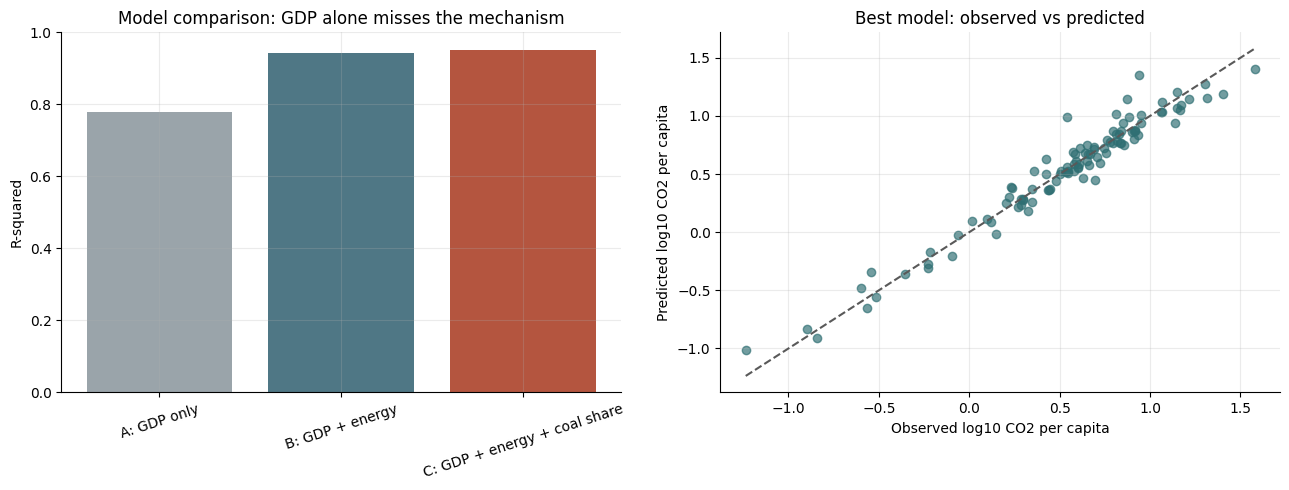

,country,co2_per_capita,gdp_per_capita,energy_per_capita,coal_share,model_residual
44118,Sweden,3.465,"47,124.891","59,279.207",0.196,-0.448
41362,Singapore,8.661,"81,736.331","158,521.719",0.032,-0.411
34908,Norway,7.483,"88,390.413","97,780.367",0.095,-0.271
12404,Democratic Republic of Congo,0.058,891.774,363.371,0.011,-0.226
36583,Panama,2.660,"21,533.053","23,285.066",0.187,-0.205
31259,Mozambique,0.285,962.809,"1,720.951",0.004,-0.205
17164,Finland,6.525,"40,607.410","57,499.422",0.358,-0.201
7210,Brazil,2.283,"15,156.043","17,744.193",0.130,-0.164


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(model_comparison['model'], model_comparison['r_squared'], color=['#9aa4aa', '#4f7785', '#b4553f'])
axes[0].set_ylim(0, 1)
axes[0].set_ylabel('R-squared')
axes[0].set_title('Model comparison: GDP alone misses the mechanism')
axes[0].tick_params(axis='x', rotation=18)

axes[1].scatter(model_df['log_co2_per_capita'], model_df['predicted_log_co2_per_capita'], alpha=0.68, color='#2f6f73')
lims = [
    min(model_df['log_co2_per_capita'].min(), model_df['predicted_log_co2_per_capita'].min()),
    max(model_df['log_co2_per_capita'].max(), model_df['predicted_log_co2_per_capita'].max()),
]
axes[1].plot(lims, lims, color='0.35', linestyle='--')
axes[1].set_xlabel('Observed log10 CO2 per capita')
axes[1].set_ylabel('Predicted log10 CO2 per capita')
axes[1].set_title('Best model: observed vs predicted')

fig.tight_layout()
fig.savefig(FIGURES / 'h2_model_comparison.png', dpi=180)
plt.show()

model_df[['country', 'co2_per_capita', 'gdp_per_capita', 'energy_per_capita', 'coal_share', 'model_residual']].sort_values('model_residual').head(8)


### Interpretation: Energy Mix

The energy-mix section explains why countries with similar levels of development can have very different emissions profiles. H2A is supported by the 2024 fuel data. Among countries with population above one million and more than 20 million tonnes of annual CO2, countries where coal makes up at least half of coal+oil+gas emissions average about 0.274 kg CO2 per kWh of primary energy. Countries where coal contributes less than 20% average about 0.168 kg CO2 per kWh. The gap is large: about 0.106 kg CO2 per kWh, and the permutation test makes that gap hard to dismiss as random grouping noise.

H2B is also strongly supported. In 2022, energy use per capita and CO2 per capita have a Spearman correlation of about 0.970. The multivariate model adds a stronger check: GDP alone predicts part of the footprint, but adding energy use per person sharply improves fit, and coal share adds structural information about the carbon content of that energy. The result is not causal proof, but it is a much better argument than simply saying rich countries emit more.


## Hypothesis 3: Trade, Responsibility, and Structural Change

**H3A:** Production-based and consumption-based emissions change which countries look responsible.

**H3B:** Some countries show declining emissions over time, which is consistent with policy, technology, and structural economic change, although the dataset alone cannot prove the exact cause.


In [20]:
h3 = countries[countries['year'] == 2023].dropna(
    subset=['co2', 'consumption_co2', 'trade_co2_share', 'population']
).copy()
h3 = h3[(h3['population'] >= 1_000_000) & (h3['co2'] > 5)]

h3[['country', 'co2', 'consumption_co2', 'trade_co2_share']].sort_values(
    'trade_co2_share', ascending=False
).head(10)

,country,co2,consumption_co2,trade_co2_share
21118,Hong Kong,32.957,144.164,337.429
44294,Switzerland,31.977,118.330,270.040
41363,Singapore,51.068,186.926,266.036
31960,Nepal,18.348,47.279,157.683
43582,Sri Lanka,19.166,46.439,142.300
5438,Belgium,84.703,196.605,132.110
25603,Latvia,6.590,13.362,102.763
7036,Botswana,7.249,14.509,100.160
8461,Cambodia,21.412,39.064,82.444
10981,Costa Rica,8.473,14.692,73.405


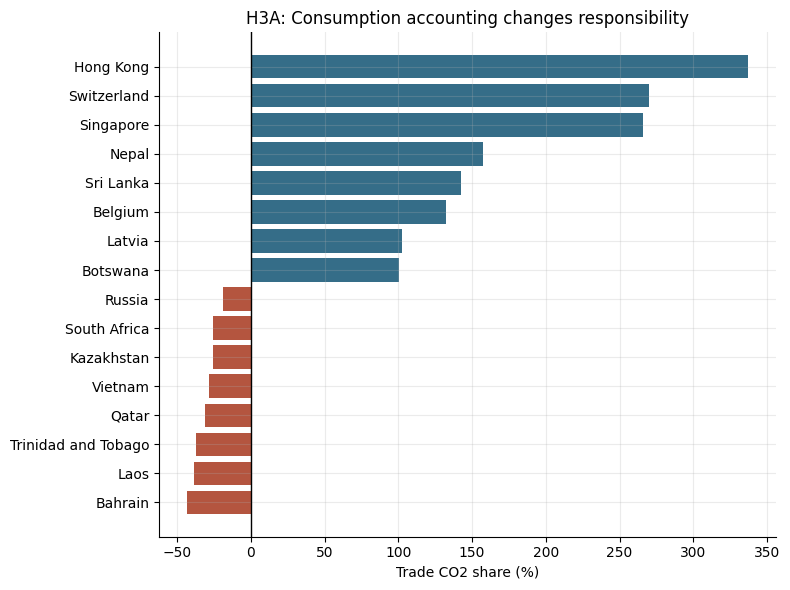

In [21]:
importers = h3.sort_values('trade_co2_share', ascending=False).head(8)
exporters = h3.sort_values('trade_co2_share', ascending=True).head(8)
trade_plot = pd.concat([exporters, importers]).sort_values('trade_co2_share')

fig, ax = plt.subplots(figsize=(8, 6))
colors = ['#b4553f' if v < 0 else '#356d88' for v in trade_plot['trade_co2_share']]
ax.barh(trade_plot['country'], trade_plot['trade_co2_share'], color=colors)
ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel('Trade CO2 share (%)')
ax.set_title('H3A: Consumption accounting changes responsibility')
fig.tight_layout()
fig.savefig(FIGURES / 'h3a_trade_co2_share.png', dpi=180)
plt.show()

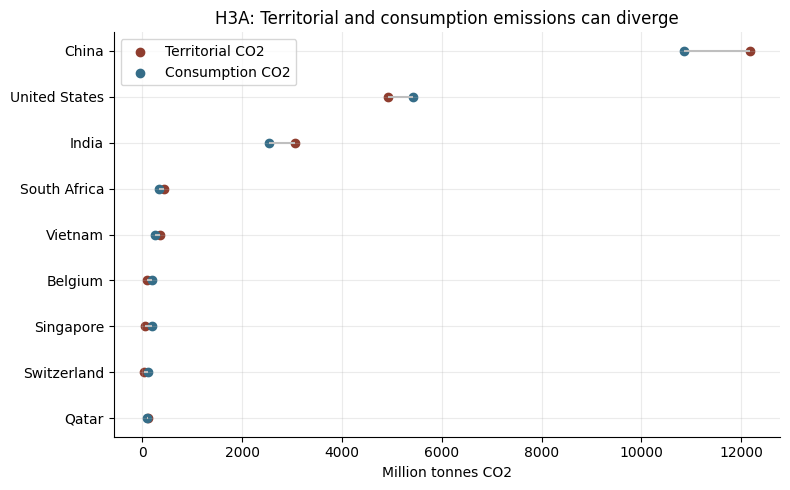

In [22]:
selected = ['Switzerland', 'Singapore', 'Belgium', 'United States', 'China', 'India', 'Vietnam', 'South Africa', 'Qatar']
pairs = h3[h3['country'].isin(selected)].sort_values('consumption_co2')

fig, ax = plt.subplots(figsize=(8, 5))
y = np.arange(len(pairs))
ax.hlines(y, pairs['co2'], pairs['consumption_co2'], color='0.75')
ax.scatter(pairs['co2'], y, label='Territorial CO2', color='#8f3d2e')
ax.scatter(pairs['consumption_co2'], y, label='Consumption CO2', color='#356d88')
ax.set_yticks(y)
ax.set_yticklabels(pairs['country'])
ax.set_xlabel('Million tonnes CO2')
ax.set_title('H3A: Territorial and consumption emissions can diverge')
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES / 'h3a_territorial_vs_consumption.png', dpi=180)
plt.show()

year,country,1990,2024,pct_change_since_1990
5,United Kingdom,601.945,312.906,-48.018
2,Germany,"1,054.796",572.319,-45.741
6,United States,"5,131.761","4,904.120",-4.436
4,South Africa,312.934,439.831,40.551
0,Brazil,218.658,483.012,120.898
1,China,"2,483.534","12,289.037",394.821
3,India,577.987,"3,193.478",452.517


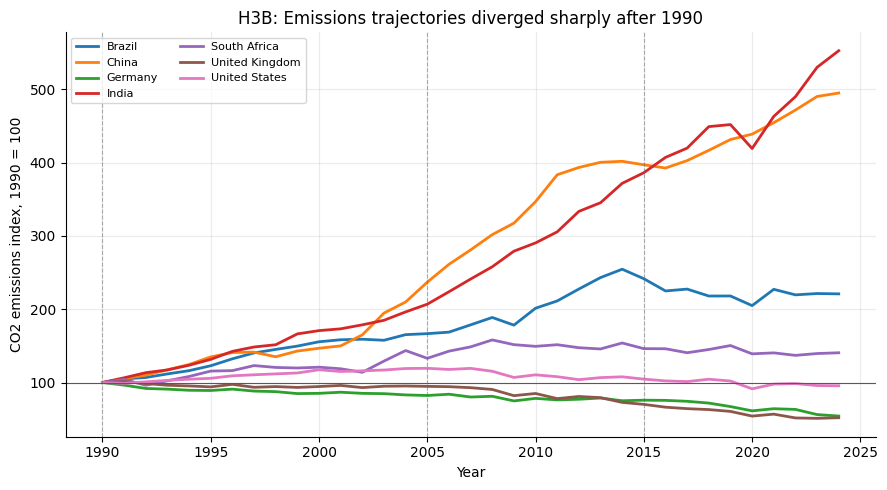

In [23]:
trend_countries = ['United States', 'China', 'India', 'Germany', 'United Kingdom', 'Brazil', 'South Africa']
base_year = 1990
trend = countries[countries['country'].isin(trend_countries) & (countries['year'] >= base_year)].copy()
trend = trend.dropna(subset=['co2'])
base = trend[trend['year'] == base_year][['country', 'co2']].rename(columns={'co2': 'base_co2'})
trend = trend.merge(base, on='country', how='inner')
trend['co2_index_1990_100'] = 100 * trend['co2'] / trend['base_co2']

latest_trend_year = int(trend['year'].max())
change_table = (
    trend[trend['year'].isin([base_year, latest_trend_year])]
    .pivot(index='country', columns='year', values='co2')
    .reset_index()
)
change_table['pct_change_since_1990'] = 100 * (change_table[latest_trend_year] / change_table[base_year] - 1)
display(change_table.sort_values('pct_change_since_1990'))

fig, ax = plt.subplots(figsize=(9, 5))
for country, g in trend.groupby('country'):
    ax.plot(g['year'], g['co2_index_1990_100'], label=country, linewidth=2)
for year in [1990, 2005, 2015]:
    ax.axvline(year, color='0.4', linewidth=0.8, linestyle='--', alpha=0.5)
ax.axhline(100, color='0.35', linewidth=0.8)
ax.set_ylabel('CO2 emissions index, 1990 = 100')
ax.set_xlabel('Year')
ax.set_title('H3B: Emissions trajectories diverged sharply after 1990')
ax.legend(ncol=2, fontsize=8)
fig.tight_layout()
fig.savefig(FIGURES / 'h3b_trend_co2_index_1990.png', dpi=180)
plt.show()


### Interpretation: Trade, Responsibility, and Structural Change

The policy and trade section shows that responsibility changes when emissions are counted by consumption instead of production. H3A is supported by the 2023 consumption-based data. Countries such as Switzerland, Singapore, Hong Kong, and Belgium have consumption emissions far above their territorial emissions, meaning a large part of their carbon footprint is embedded in imported goods and services. Switzerland's trade-adjusted share is about +270%, Singapore's is about +266%, and Belgium's is about +132%. In contrast, Bahrain, Qatar, Vietnam, Kazakhstan, South Africa, Russia, and India have negative trade adjustments, meaning they produce more emissions domestically than their residents consume directly.

This matters because territorial accounting can make importer economies look cleaner than they are, while making exporter or manufacturing economies look dirtier. A fair climate discussion should therefore include both numbers: production emissions show where CO2 physically enters the atmosphere, while consumption emissions show who ultimately benefits from the goods being produced.

H3B is supported more cautiously. The indexed trend graph shows that some countries have reduced annual CO2 emissions since 1990, while others have grown sharply. By 2024, the United Kingdom and Germany are near 52% and 54% of their 1990 emissions, respectively. The United States is slightly below its 1990 level, while China and India are roughly five times higher. These declines are consistent with policy, technology shifts, deindustrialization, and cleaner energy, but this dataset alone cannot prove the exact cause. The correct claim is structural change, not simple policy causality.


## Hypothesis 4: Land-Use Change Complicates the Fossil CO2 Story

**H4:** For some countries, excluding land-use change substantially understates the emissions story.

This matters because the assignment theme includes natural resources and structural choices. Fossil-fuel CO2 is not the only national emissions pathway. Land-use change can add or subtract large amounts, especially in forest, agricultural, and land-conversion economies.


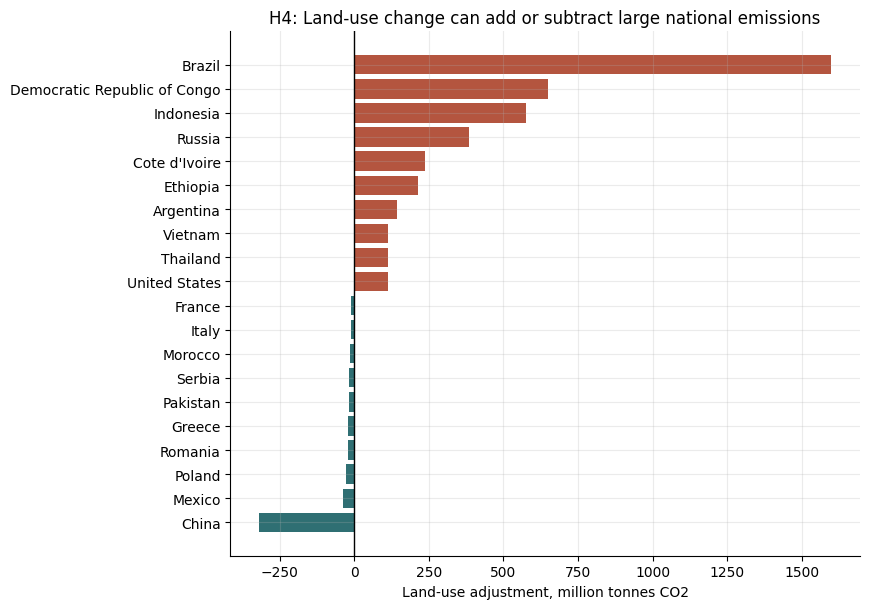

,country,co2,co2_including_luc,land_use_change_co2,luc_gap,luc_share_of_fossil_co2
7212,Brazil,483.012,"2,082.678","1,599.667","1,599.666",331.186
12406,Democratic Republic of Congo,5.904,654.101,648.196,648.197,"10,978.946"
21937,Indonesia,812.220,"1,388.412",576.192,576.192,70.940
38314,Russia,"1,780.524","2,166.402",385.877,385.878,21.672
11257,Cote d'Ivoire,14.829,252.400,237.571,237.571,"1,602.070"
14992,Ethiopia,17.837,231.873,214.036,214.036,"1,199.955"
2324,Argentina,171.059,315.465,144.406,144.406,84.419
49336,Vietnam,370.931,484.165,113.234,113.234,30.527
45274,Thailand,267.760,380.000,112.240,112.240,41.918
48007,United States,"4,904.120","5,016.179",112.059,112.059,2.285


In [24]:
h4 = countries[countries['year'] == 2024].dropna(
    subset=['co2', 'co2_including_luc', 'land_use_change_co2', 'population']
).copy()
h4 = h4[h4['population'] >= 1_000_000]
h4['luc_gap'] = h4['co2_including_luc'] - h4['co2']
h4['luc_share_of_fossil_co2'] = 100 * h4['luc_gap'] / h4['co2'].replace(0, np.nan)

positive_luc = h4.nlargest(10, 'luc_gap')
negative_luc = h4.nsmallest(10, 'luc_gap')
luc_plot = pd.concat([negative_luc, positive_luc]).sort_values('luc_gap')

fig, ax = plt.subplots(figsize=(8.8, 6.2))
colors = ['#2f6f73' if v < 0 else '#b4553f' for v in luc_plot['luc_gap']]
ax.barh(luc_plot['country'], luc_plot['luc_gap'], color=colors)
ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel('Land-use adjustment, million tonnes CO2')
ax.set_title('H4: Land-use change can add or subtract large national emissions')
fig.tight_layout()
fig.savefig(FIGURES / 'h4_land_use_adjustment.png', dpi=180)
plt.show()

h4[['country', 'co2', 'co2_including_luc', 'land_use_change_co2', 'luc_gap', 'luc_share_of_fossil_co2']].sort_values('luc_gap', ascending=False).head(12)


### Interpretation: Land Use

H4 is supported for a subset of countries. The land-use adjustment is not a rounding error: in some cases it adds hundreds of millions of tonnes of CO2 responsibility to the fossil-fuel total, while in others land sinks or accounting differences pull the combined number downward. This does not replace the energy-system story, but it prevents a misleading conclusion that national emissions are only about industry and electricity. For countries with major forest loss, peatland disturbance, agricultural expansion, or land restoration, land-use accounting changes the policy interpretation.


## Conclusion

National CO2 emissions are not explained by wealth alone. Economic development is associated with higher per-person emissions, but the final emissions outcome depends on how much energy people use, whether that energy comes from coal-heavy systems, whether emissions are counted where goods are produced or consumed, whether land-use change is included, and whether countries have managed to bend their emissions trend downward over time.

A fair interpretation combines several lenses. Economic capacity helps explain who can consume more energy; fuel mix explains how carbon-intensive that energy is; trade accounting shows who benefits from emissions that may occur somewhere else; land-use accounting captures natural-resource and land-management pressures; and trend analysis shows whether a country is moving onto a different pathway.

### Limitations

This is an observational notebook. It can show associations, concentration, and trajectory changes, but it cannot prove a specific policy caused a specific emissions outcome without additional policy, electricity-generation, trade, and sector-level data. GDP and consumption indicators also lag the latest territorial CO2 year, so the analysis uses different years for different hypotheses.
